<a href="https://colab.research.google.com/github/Dexter0013/Vision-Transformer/blob/main/Quick_inference_with_VideoMAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Set-up environment

First, let's install 🤗 Transformers and decord, which we'll use to decode a video.

In [1]:
!pip install -q git+https://github.com/huggingface/transformers.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
!pip install -q decord

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 46.6 MB/s eta 0:00:00


## Load video

Let's load a video from the [Kinetics-400](https://www.deepmind.com/open-source/kinetics) dataset. This dataset contains millions of YouTube videos annotated with one out of 400 possible classes.



In [12]:
!wget https://huggingface.co/datasets/nielsr/video-demo/resolve/main/eating_spaghetti.mp4

--2026-07-06 07:27:00--  https://huggingface.co/datasets/nielsr/video-demo/resolve
Resolving huggingface.co (huggingface.co)... 18.164.174.118, 18.164.174.55, 18.164.174.17, ...
Connecting to huggingface.co (huggingface.co)|18.164.174.118|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-07-06 07:27:00 ERROR 404: Not Found.



In [32]:
from ipywidgets import Video

video_path = "/content/ucf101_5pct/Haircut/v_Haircut_g11_c04.avi"
Video.from_file(video_path, width=500)

Video(value=b'RIFF\xc8\x81\x07\x00AVI LIST~\x01\x00\x00hdrlavih8\x00\x00\x00@\x9c\x00\x00\x00\x00\x00\x00\x00\…

## Prepare video for model

We can prepare the video for the model using VideoMAEFeatureExtractor. We'll first sample 16 frames (out of the possible 300), and provide this to the feature extractor.

It will perform some basic preprocessing, namely resize, center crop and normalize each frame of the video.

In [3]:
from transformers import AutoProcessor

processor = AutoProcessor.from_pretrained("MCG-NJU/videomae-base-finetuned-kinetics")

preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/22.9k [00:00<?, ?B/s]

In [33]:
from decord import VideoReader, cpu
import numpy as np

# video clip consists of 300 frames (10 seconds at 30 FPS)
vr = VideoReader(video_path, num_threads=1, ctx=cpu(0))

def sample_frame_indices(clip_len, frame_sample_rate, seg_len):
  converted_len = int(clip_len * frame_sample_rate)
  end_idx = np.random.randint(converted_len, seg_len)
  str_idx = end_idx - converted_len
  index = np.linspace(str_idx, end_idx, num=clip_len)
  index = np.clip(index, str_idx, end_idx - 1).astype(np.int64)

  return index

vr.seek(0)
index = sample_frame_indices(clip_len=16, frame_sample_rate=4, seg_len=len(vr))
buffer = vr.get_batch(index).asnumpy()
buffer.shape

(16, 240, 320, 3)

In [34]:
# create a list of NumPy arrays
video = [buffer[i] for i in range(buffer.shape[0])]

encoding = processor(video, return_tensors="pt")
print(encoding.pixel_values.shape)

torch.Size([1, 16, 3, 224, 224])


## Load model

Next, let's load the model and move it to the GPU, if it's available.

In [5]:
from transformers import VideoMAEForVideoClassification
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model = VideoMAEForVideoClassification.from_pretrained("MCG-NJU/videomae-large-finetuned-kinetics")
model.to(device)

config.json:   0%|          | 0.00/22.9k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/318 [00:00<?, ?it/s]

[transformers] VideoMAEForVideoClassification LOAD REPORT from: MCG-NJU/videomae-large-finetuned-kinetics
Key                                                            | Status     | 
---------------------------------------------------------------+------------+-
videomae.encoder.layer.{0...23}.attention.attention.q_bias     | UNEXPECTED | 
videomae.encoder.layer.{0...23}.attention.attention.v_bias     | UNEXPECTED | 
videomae.encoder.layer.{0...23}.attention.attention.key.bias   | MISSING    | 
videomae.encoder.layer.{0...23}.attention.attention.query.bias | MISSING    | 
videomae.encoder.layer.{0...23}.attention.attention.value.bias | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


VideoMAEForVideoClassification(
  (videomae): VideoMAEModel(
    (embeddings): VideoMAEEmbeddings(
      (patch_embeddings): VideoMAEPatchEmbeddings(
        (projection): Conv3d(3, 1024, kernel_size=(2, 16, 16), stride=(2, 16, 16))
      )
    )
    (encoder): VideoMAEEncoder(
      (layer): ModuleList(
        (0-23): 24 x VideoMAELayer(
          (attention): VideoMAEAttention(
            (attention): VideoMAESelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=True)
              (key): Linear(in_features=1024, out_features=1024, bias=True)
              (value): Linear(in_features=1024, out_features=1024, bias=True)
            )
            (output): VideoMAESelfOutput(
              (dense): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): VideoMAEIntermediate(
            (dense): Linear(in_features=1024, out_features=4096, bias=Tru

## Forward pass

In [35]:
pixel_values = encoding.pixel_values.to(device)

# forward pass
with torch.no_grad():
  outputs = model(pixel_values)
  logits = outputs.logits

In [36]:
predicted_class_idx = logits.argmax(-1).item()

print("Predicted class:", model.config.id2label[predicted_class_idx])

Predicted class: getting a haircut


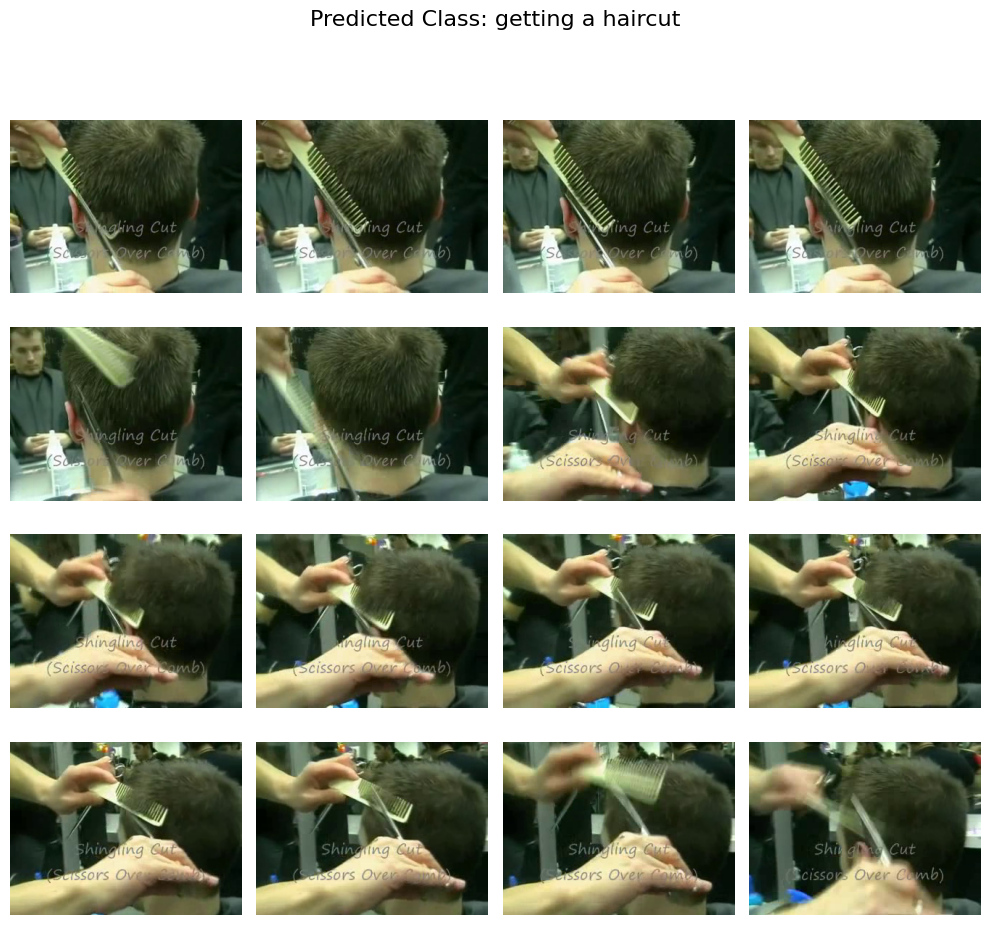

In [37]:
import matplotlib.pyplot as plt

predicted_label = model.config.id2label[predicted_class_idx]

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle(f"Predicted Class: {predicted_label}", fontsize=16)

for i, ax in enumerate(axes.flat):
    if i < len(video):
        ax.imshow(video[i])
        ax.axis('off')
    else:
        ax.remove()

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

In [6]:
from google.colab import userdata
import os, json

os.makedirs('/root/.kaggle', exist_ok=True)
creds = {
    "username": userdata.get('KAGGLE_USERNAME'),
    "key": userdata.get('KAGGLE_KEY')
}
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(creds, f)
os.system('chmod 600 /root/.kaggle/kaggle.json')

0

In [7]:
# 1. Setup Kaggle credentials (skip if already done)
import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.system('mv kaggle.json /root/.kaggle/kaggle.json')
os.system('chmod 600 /root/.kaggle/kaggle.json')

# 2. Download
!kaggle datasets download -d matthewjansen/ucf101-action-recognition -p /content/data
!unzip -q /content/data/ucf101-action-recognition.zip -d /content/data/ucf101

# 3. Check structure
import os
print(os.listdir('/content/data/ucf101'))

Dataset URL: https://www.kaggle.com/datasets/matthewjansen/ucf101-action-recognition
License(s): CC0-1.0
100% 6.53G/6.53G [01:47<00:00, 65.4MB/s]

['val', 'val.csv', 'test.csv', 'train.csv', 'train', 'test']


In [8]:
import random
import os
from pathlib import Path

# --- Step 3: Build stratified 5% subset ---
def build_test_subset(dataset_dir, output_dir, fraction=0.05, min_per_class=2, seed=42):
    random.seed(seed)
    dataset_dir = Path(dataset_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    summary = {}
    for class_dir in sorted(dataset_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        videos = list(class_dir.glob("*"))
        if not videos:
            continue
        n_take = max(min_per_class, int(len(videos) * fraction))
        n_take = min(n_take, len(videos))
        sampled = random.sample(videos, n_take)

        out_class_dir = output_dir / class_dir.name
        out_class_dir.mkdir(parents=True, exist_ok=True)
        for video in sampled:
            link_path = out_class_dir / video.name
            if not link_path.exists():
                os.symlink(video.resolve(), link_path)

        summary[class_dir.name] = n_take

    print(f"Subset built at {output_dir}")
    print(f"Total classes: {len(summary)}, total clips: {sum(summary.values())})")
    for cls, n in summary.items():
        print(f"  {cls}: {n} clips")
    return summary

summary = build_test_subset(
    dataset_dir="/content/data/ucf101/train",   # adjust based on actual unzipped structure
    output_dir="/content/ucf101_5pct",
    fraction=0.05,
    min_per_class=2
)

Subset built at /content/ucf101_5pct
Total classes: 101, total clips: 456)
  ApplyEyeMakeup: 5 clips
  ApplyLipstick: 4 clips
  Archery: 5 clips
  BabyCrawling: 4 clips
  BalanceBeam: 4 clips
  BandMarching: 5 clips
  BaseballPitch: 5 clips
  Basketball: 9 clips
  BasketballDunk: 4 clips
  BenchPress: 6 clips
  Biking: 5 clips
  Billiards: 5 clips
  BlowDryHair: 4 clips
  BlowingCandles: 4 clips
  BodyWeightSquats: 4 clips
  Bowling: 5 clips
  BoxingPunchingBag: 6 clips
  BoxingSpeedBag: 5 clips
  BreastStroke: 3 clips
  BrushingTeeth: 4 clips
  CleanAndJerk: 4 clips
  CliffDiving: 5 clips
  CricketBowling: 5 clips
  CricketShot: 6 clips
  CuttingInKitchen: 4 clips
  Diving: 5 clips
  Drumming: 6 clips
  Fencing: 4 clips
  FieldHockeyPenalty: 4 clips
  FloorGymnastics: 4 clips
  FrisbeeCatch: 4 clips
  FrontCrawl: 5 clips
  GolfSwing: 5 clips
  Haircut: 4 clips
  HammerThrow: 5 clips
  Hammering: 5 clips
  HandstandPushups: 4 clips
  HandstandWalking: 4 clips
  HeadMassage: 5 clips
  H